# Business Understanding

## Latar Belakang

Kualitas beras merupakan salah satu faktor penting dalam industri pangan. Identifikasi varietas beras secara manual membutuhkan waktu dan rentan terhadap kesalahan manusia. Oleh karena itu diperlukan sistem klasifikasi citra berbasis machine learning untuk membantu proses identifikasi varietas beras secara otomatis.

## Tujuan

Mempersiapkan dataset Rice Image Dataset agar siap digunakan pada proses pelatihan model klasifikasi citra beras.

## Output

Dataset preprocessing yang telah dibagi menjadi data train, validation, dan test serta telah dinormalisasi sehingga siap digunakan untuk proses pelatihan model.

# Data Understanding

Dataset yang digunakan adalah Rice Image Dataset yang terdiri dari lima kelas varietas beras:

- Arborio
- Basmati
- Ipsala
- Jasmine
- Karacadag

Dataset berisi 75.000 citra beras dengan distribusi yang seimbang pada setiap kelas.

# Import Library

In [30]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import splitfolders

from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image

# Data Loading

Pada tahap ini dilakukan pembacaan dataset Rice Image Dataset yang terdiri dari lima kelas varietas beras, yaitu Arborio, Basmati, Ipsala, Jasmine, dan Karacadag.

In [47]:
# Menentukan path dataset
dataset_path = os.path.abspath("../dataset_raw/Rice_Image_Dataset")

print("="*50)
print("DATA LOADING")
print("="*50)

print(f"Lokasi Dataset: {dataset_path}")

if os.path.exists(dataset_path):
    print("\nDataset berhasil ditemukan.")
else:
    print("\nDataset tidak ditemukan.")

classes = sorted([
    item for item in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, item))
])

print("\nIsi Folder Dataset:")
print(classes)

print("\nDaftar Kelas:")
for i, kelas in enumerate(classes, start=1):
    print(f"{i}. {kelas}")

print(f"\nJumlah Kelas: {len(classes)}")

DATA LOADING
Lokasi Dataset: d:\Ulan\Project\MLOps\Eksperimen_SML_Sri Ulan\dataset_raw\Rice_Image_Dataset

Dataset berhasil ditemukan.

Isi Folder Dataset:
['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']

Daftar Kelas:
1. Arborio
2. Basmati
3. Ipsala
4. Jasmine
5. Karacadag

Jumlah Kelas: 5


# EDA (Exploratory Data Analysis)

Pada tahap ini dilakukan eksplorasi dataset untuk memahami karakteristik data, distribusi kelas, serta ukuran citra yang digunakan.

## Menghitung Jumlah Gambar per Kelas

In [34]:
print("\nJumlah Gambar per Kelas")
print("="*30)

for kelas in classes:

    folder = os.path.join(dataset_path, kelas)

    jumlah = len(os.listdir(folder))

    print(f"{kelas}: {jumlah} gambar")


Jumlah Gambar per Kelas
Arborio: 15000 gambar
Basmati: 15000 gambar
Ipsala: 15000 gambar
Jasmine: 15000 gambar
Karacadag: 15000 gambar


## Analisis Distribusi Dataset

In [35]:
jumlah_gambar = []

for kelas in classes:

    folder = os.path.join(dataset_path, kelas)

    jumlah = len(os.listdir(folder))

    jumlah_gambar.append(jumlah)

total_gambar = sum(jumlah_gambar)

print("Total Gambar:", total_gambar)

for kelas, jumlah in zip(classes, jumlah_gambar):

    persentase = (jumlah / total_gambar) * 100

    print(f"{kelas}: {persentase:.2f}%")

Total Gambar: 75000
Arborio: 20.00%
Basmati: 20.00%
Ipsala: 20.00%
Jasmine: 20.00%
Karacadag: 20.00%


## Analisis Distribusi Dataset

Dataset terdiri dari 5 kelas varietas beras dengan jumlah gambar yang sama pada setiap kelas yaitu 15.000 gambar.

Total dataset berjumlah 75.000 gambar sehingga distribusi data bersifat seimbang (balanced dataset). Kondisi ini membantu model mengurangi bias terhadap kelas tertentu selama proses pelatihan.

## Visualisasi Distribusi Dataset

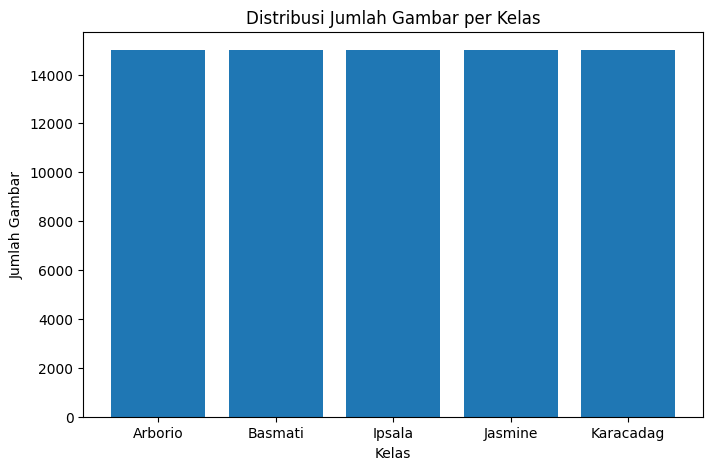

In [36]:
plt.figure(figsize=(8,5))

plt.bar(classes, jumlah_gambar)

plt.title("Distribusi Jumlah Gambar per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")

plt.show()

## Visualisasi Contoh Gambar Setiap Kelas

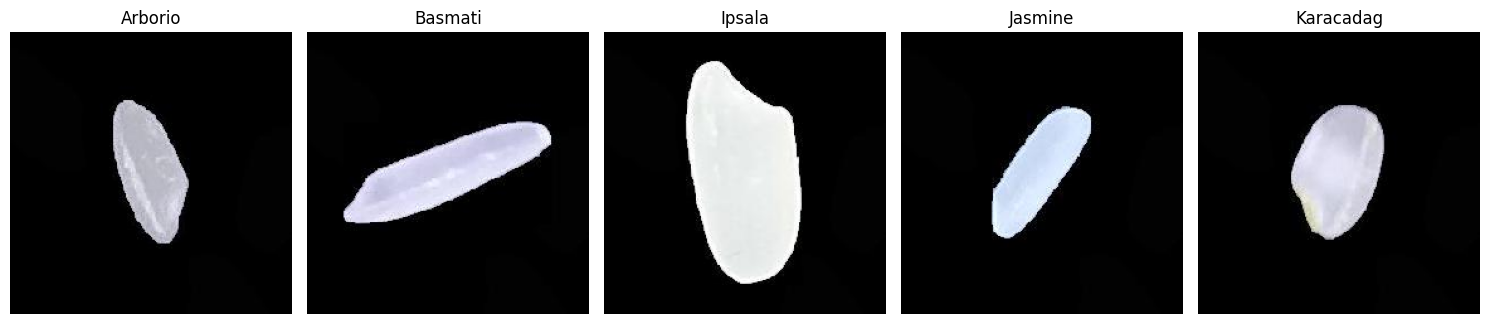

In [37]:
plt.figure(figsize=(15,5))

for i, kelas in enumerate(classes):

    folder = os.path.join(dataset_path, kelas)

    img_name = random.choice(os.listdir(folder))

    img_path = os.path.join(folder, img_name)

    img = load_img(img_path, target_size=(224,224))

    plt.subplot(1,5,i+1)

    plt.imshow(img)

    plt.title(kelas)

    plt.axis("off")

plt.tight_layout()

plt.show()

## Analisis Ukuran Gambar

In [38]:
print("Ukuran Sampel Gambar")
print("="*30)

for kelas in classes:

    folder = os.path.join(dataset_path, kelas)

    sample = random.choice(os.listdir(folder))

    sample_path = os.path.join(folder, sample)

    img = Image.open(sample_path)

    print(f"{kelas}: {img.size}")

Ukuran Sampel Gambar
Arborio: (250, 250)
Basmati: (250, 250)
Ipsala: (250, 250)
Jasmine: (250, 250)
Karacadag: (250, 250)


## Kesimpulan EDA

Berdasarkan hasil eksplorasi data diperoleh beberapa informasi sebagai berikut:

1. Dataset terdiri dari 5 kelas varietas beras yaitu Arborio, Basmati, Ipsala, Jasmine, dan Karacadag.
2. Total dataset berjumlah 75.000 gambar.
3. Setiap kelas memiliki jumlah gambar yang sama yaitu 15.000 gambar sehingga distribusi dataset seimbang.
4. Ukuran gambar relatif seragam sehingga memudahkan proses preprocessing dan pelatihan model klasifikasi citra.
5. Dataset siap digunakan untuk proses preprocessing dan pembangunan model machine learning/deep learning.

# Preprocessing

Tahap preprocessing dilakukan untuk menghasilkan dataset yang siap digunakan pada proses pelatihan model machine learning.

Tahapan preprocessing meliputi:

1. Split dataset menjadi train, validation, dan test.
2. Resizing gambar menjadi 224x224 piksel.
3. Normalisasi nilai piksel ke rentang 0–1.
4. Verifikasi hasil preprocessing.

## Split Dataset

In [ ]:
splitfolders.ratio(
    dataset_path,
    output="dataset_preprocessing",
    seed=42,
    ratio=(0.7, 0.15, 0.15)
)

## Menentukan Parameter Preprocessing

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_dir = "dataset_preprocessing/train"
val_dir = "dataset_preprocessing/val"
test_dir = "dataset_preprocessing/test"

## Normalisasi Data

In [41]:
train_datagen = ImageDataGenerator(
    rescale=1./255
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

Normalisasi dilakukan dengan membagi setiap nilai piksel dengan 255 sehingga rentang nilai berubah dari 0–255 menjadi 0–1. Proses ini membantu model lebih cepat konvergen saat pelatihan.

## Resizing dan Loading Dataset

In [42]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 52500 images belonging to 5 classes.
Found 11250 images belonging to 5 classes.
Found 11250 images belonging to 5 classes.


Seluruh gambar diubah ukurannya menjadi 224×224 piksel agar memiliki dimensi yang seragam sebelum digunakan dalam proses pelatihan model CNN.

# Verifikasi Hasil Preprocessing

## Verifikasi Jumlah Data Train, Validation, dan Test

In [43]:
base_path = "../dataset_preprocessing"

for subset in ["train", "val", "test"]:

    print(f"\n{subset.upper()}")
    print("-"*30)

    subset_path = os.path.join(base_path, subset)

    total = 0

    for kelas in classes:

        kelas_path = os.path.join(subset_path, kelas)

        jumlah = len(os.listdir(kelas_path))

        total += jumlah

        print(f"{kelas}: {jumlah}")

    print(f"Total {subset}: {total}")


TRAIN
------------------------------
Arborio: 10500
Basmati: 10500
Ipsala: 10500
Jasmine: 10500
Karacadag: 10500
Total train: 52500

VAL
------------------------------
Arborio: 2250
Basmati: 2250
Ipsala: 2250
Jasmine: 2250
Karacadag: 2250
Total val: 11250

TEST
------------------------------
Arborio: 2250
Basmati: 2250
Ipsala: 2250
Jasmine: 2250
Karacadag: 2250
Total test: 11250


## Verifikasi Dataset Berhasil Dibaca TensorFlow

In [44]:
print("Train Samples :", train_generator.samples)
print("Validation Samples :", val_generator.samples)
print("Test Samples :", test_generator.samples)

Train Samples : 52500
Validation Samples : 11250
Test Samples : 11250


## Verifikasi Shape Data Setelah Preprocessing

In [45]:
images, labels = next(train_generator)

print("Shape Images :", images.shape)
print("Shape Labels :", labels.shape)

Shape Images : (32, 224, 224, 3)
Shape Labels : (32, 5)


## Kesimpulan Verifikasi Preprocessing

Berdasarkan hasil verifikasi:

1. Dataset berhasil dibagi menjadi data train, validation, dan test dengan rasio 70:15:15.
2. Seluruh data berhasil dibaca menggunakan ImageDataGenerator.
3. Gambar berhasil diubah ukurannya menjadi 224×224 piksel.
4. Data telah dinormalisasi ke rentang 0–1 menggunakan rescale=1./255.
5. Dataset siap digunakan untuk proses pelatihan model klasifikasi citra.

# Kesimpulan

Berdasarkan proses eksperimen yang telah dilakukan:

- Dataset berhasil dimuat dan dianalisis.
- Dataset memiliki distribusi kelas yang seimbang.
- Seluruh gambar memiliki ukuran yang seragam.
- Dataset berhasil diproses melalui tahapan split, resizing, dan normalisasi.
- Dataset preprocessing siap digunakan untuk proses pelatihan model klasifikasi citra beras.